In [1]:
import collections
import functools as ft
import itertools as it
import json
import multiprocessing as mp
import sys
from pathlib import Path
from typing import Tuple, Dict, List, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, SelectorMixin
from sklearn.metrics import get_scorer, confusion_matrix, matthews_corrcoef
from sklearn.base import BaseEstimator, clone
from sklearn.utils import check_X_y
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from Bio.Phylo.BaseTree import Tree
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedShuffleSplit, cross_validate, StratifiedKFold

mkdir -p failed for path /home/user/.config/matplotlib: [Errno 13] Permission denied: '/home/user'
Matplotlib created a temporary cache directory at /tmp/matplotlib-ufd20lqq because there was an issue with the default path (/home/user/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Common functions

In [2]:
def load_dataset(datafile: str, targetfile: str) -> Tuple[pd.DataFrame, pd.Series]:
    """Dataset loading function."""

    # Load datasets
    data = pd.read_csv(datafile, index_col=0)
    target = pd.read_csv(targetfile, index_col=0).iloc[:, 0]

    # Filter to classes with frequency > 1
    counts = target.value_counts()
    target = target[target.isin(counts[counts > 1].index)]

    # Filter to common indices of data and target
    common_index = list(set(data.index) & set(target.index))
    data = data.loc[common_index]
    target = target.loc[common_index]

    # Remove features with zero variance
    var_support = VarianceThreshold().fit(data).get_support(indices=True)
    data = data[data.columns[var_support]]

    # Merge columns with the same values and concatenate their names
    new_columns: Dict[Tuple, str] = {}
    for column in data.columns:
        values = tuple(data[column])
        if values not in new_columns:
            new_columns[values] = str(column)
        else:
            new_columns[values] = ",".join([new_columns[values], str(column)])
    
    data = pd.DataFrame(
        {value: key for key, value in new_columns.items()},
        index=data.index
    )

    return data, target

In [3]:
def load_dataset_alt(datafile: str, targetfile: str) -> Tuple[pd.DataFrame, pd.Series]:
    """Dataset loading alternative for pancluster."""

    # Load datasets
    data = pd.read_csv(datafile, index_col=0)
    target = pd.read_csv(targetfile, index_col=0).iloc[:, 0]

    # Filter to classes with frequency > 1
    counts = target.value_counts()
    target = target[target.isin(counts[counts > 1].index)]

    # Filter to common indices of data and target
    common_index = list(set(data.index) & set(target.index))
    data = data.loc[common_index]
    target = target.loc[common_index]

    # Remove features with zero variance
    var_support = VarianceThreshold().fit(data).get_support(indices=True)
    data = data[data.columns[var_support]]

    subsets: List[pd.DataFrame] = []

    # Merge columns belonging to the same GCF and having the same values
    for gcf in data.columns.str.split("_").str.get(0).unique():
        subset = data[data.columns[data.columns.str.startswith(f"{gcf}_")]]
        new_columns: Dict[tuple, str] = {}
        
        for column in subset.columns:
            values = tuple(subset[column])
            if values not in new_columns:
                new_columns[values] = str(column)
            else:
                new_columns[values] = ",".join(
                    [new_columns[values], str(column)]
                )
        
        subset = pd.DataFrame(
            {value: key for key, value in new_columns.items()},
            index=subset.index
        )
        subsets.append(subset)

    return pd.concat(subsets, axis=1).fillna(0).astype(int), target

In [4]:
def remove_redundant(data: pd.DataFrame):

    # Remove features with zero variance
    var_support = VarianceThreshold().fit(data).get_support(indices=True)
    data = data[data.columns[var_support]]

    # Merge columns with the same values and concatenate their names
    new_columns: Dict[Tuple, str] = {}
    for column in data.columns:
        values = tuple(data[column])
        if values not in new_columns:
            new_columns[values] = str(column)
        else:
            new_columns[values] = ",".join([new_columns[values], str(column)])

    return pd.DataFrame(
        {value: key for key, value in new_columns.items()},
        index=data.index
    )

In [5]:
def _leave_one_out(
    index,
    model: BaseEstimator,
    data: pd.DataFrame,
    target: pd.Series,
    verbose: Union[int, bool] = False
):
    """Train model on everything except index, and predict index."""

    pred = clone(model).fit(
        data.drop(index=index), target.drop(index=index)
    ).predict(data.loc[[index]])[0]

    if verbose == 2:
        print(
            {"index": index, "pred": pred, "true": target.loc[index]},
            file=sys.stderr
        )
    
    return pred

def evaluate_model(
    model: BaseEstimator,
    data: pd.DataFrame,
    target: pd.Series,
    scoring: str = "matthews_corrcoef",
    n_jobs: int = 1,
    verbose: Union[int, bool] = False
) -> Tuple[float, pd.Series]:
    """Evaluate a model using leave-on-out approach."""

    func = ft.partial(
        _leave_one_out, model=model, data=data, target=target, verbose=verbose
    )
    with mp.Pool(n_jobs) as pool:
        if n_jobs > 1:
            predictions = pool.map(func, data.index)
        else:
            predictions = list(map(func, data.index))

    score = getattr(get_scorer(scoring), "_score_func")(target, predictions)

    if verbose:
        print({"score": score}, file=sys.stderr)

    return score, pd.Series(predictions, index=target.index)

In [6]:
def grid_search(
    model: BaseEstimator,
    params: dict,
    data: pd.DataFrame,
    target: pd.Series,
    scoring: str = "matthews_corrcoef",
    n_jobs: int = 1,
    verbose: bool = False
):
    """Own implementation of grid search."""

    grid = (dict(zip(params, val)) for val in it.product(*params.values()))
    results: List[dict] = []

    for config in grid:
        result = {
            "params": config,
            "eval": dict(zip(
                ["score", "pred"],
                evaluate_model(
                    model.set_params(**config),
                    data,
                    target,
                    scoring,
                    n_jobs
                )
            ))
        }
        results.append(result)
        if verbose:
            print(result, file=sys.stderr)

    return results

In [7]:
def to_pandas(X, y = None):
    """Transforms X into a DataFrame (useful in prince.MCA)."""

    return pd.DataFrame(X)

In [8]:
def plot_confusion_matrix(
    target: pd.Series,
    pred: pd.Series,
    scoring: str = "matthews_corrcoef"
):
    """Create a confusion matrix plot."""

    # Compute confusion matrix
    labels = sorted(target.unique())
    fig, ax = plt.subplots(figsize=(5, 4), layout="tight")
    matrix = pd.DataFrame(
        confusion_matrix(target, pred, labels=labels),
        index=pd.Series(labels, name="true"),
        columns=pd.Series(labels, name="pred")
    )

    # Create confusion heatmap
    sns.heatmap(
        matrix, ax=ax, square=True, cmap="Blues", cbar=False, annot=True,
        linewidths=0.6, linecolor="black"
    )
    for spine in ax.spines.values():
        spine.set_visible(True)

    # Add per-class OneVsRest scores
    ax2 = ax.secondary_yaxis("right")
    scorer = getattr(get_scorer(scoring), "_score_func")
    class_scores = [
        f"{scorer(target == label, pred == label):.2f}" for label in labels
    ]
    ax2.set_yticks(ax.get_yticks())
    ax2.set_yticklabels(class_scores)
    ax2.set_ylabel("per-class")

    return fig, ax

In [9]:
class VasinfectumClassifier(BaseEstimator):

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.first_ = LogisticRegression(
            random_state=0,
            solver="saga",
            max_iter=2000,
            class_weight="balanced",
            tol=1e-3
        ).fit(X, y)

        self.second_ = {}
        problematic_labels = [
            "cucumerinum", "fragariae", "lycopersici", "melonis", "niveum"
        ]

        for label in sorted(problematic_labels):
            new_y = y[y.isin(["vasinfectum", label])]
            new_X = X.loc[new_y.index]

            if label in {"fragariae", "lycopersici"}:
                est = BernoulliNB(alpha=0.07).fit(new_X, new_y)
            else:
                est = LogisticRegression(
                    random_state=0,
                    solver="saga",
                    max_iter=2000,
                    class_weight="balanced",
                    tol=1e-3,
                )
                if label == "cucumerinum":
                    est.set_params(penalty="l1")
                est.fit(new_X, new_y)

            self.second_[label] = est

        return self

    def predict(self, X: pd.DataFrame):
        preds = self.first_.predict(X)
        problematic = set(self.second_)
        problematic.add("vasinfectum")

        for index, pred in enumerate(preds):
            if pred in problematic:
                votes = [
                    self.second_[label].predict(X.iloc[[index]])[0]
                    for label in self.second_
                ].count("vasinfectum")
                print(X.index[index], votes)

        return preds

In [10]:
data, target = load_dataset(
    "data/tables/panclusters.csv",
    "data/accessions.csv"
)
data.shape

FileNotFoundError: [Errno 2] No such file or directory: 'data/tables/panclusters.csv'

### Models

BernoulliNB

In [13]:
clu, target = load_dataset("data/tables/panclusters.csv", "data/accessions.csv")
# eff, target = load_dataset("data/tables/effectors.csv", "data/accessions.csv")
# pan, target = load_dataset("data/tables/pangenome.csv", "data/accessions.csv")

In [13]:
pan = pan[['g0', 'g1', 'g2', 'g3', 'g5', 'g7', 'g9', 'g12', 'g18', 'g1016', 'g1165', 'g2096', 'g2588', 'g2818,g3149', 'g3799', 'g4334', 'g6850', 'g9839', 'g11518', 'g26710', 'g30427', 'g37155', 'g37999', 'g38070', 'g42457', 'g52192', 'g63190', 'g68260']]
pan

,g0,g1,g2,g3,g5,g7,g9,g12,g18,g1016,...,g11518,g26710,g30427,g37155,g37999,g38070,g42457,g52192,g63190,g68260
accession,,,,,,,,,,,,,,,,,,,,,
GCA_016166225.1,1,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,1,1,0,0,0
GCA_002711385.1,1,1,0,1,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
GCA_019721175.1,1,1,1,1,1,1,1,1,0,1,...,0,1,0,0,0,1,1,0,1,0
GCA_001702995.1,1,0,0,1,1,0,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
GCA_001702805.1,1,1,1,1,0,0,1,1,1,0,...,0,1,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCA_001702795.1,0,1,1,1,1,0,1,1,1,0,...,0,0,0,0,0,1,1,0,1,0
GCA_013347345.1,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,1,1,0,0,1
GCA_016166065.1,1,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,1,1,0,0,0


{'index': 'GCA_016163875.1', 'pred': np.str_('fragariae'), 'true': 'fragariae'}
{'index': 'GCA_020976115.1', 'pred': np.str_('melonis'), 'true': 'melonis'}
{'index': 'GCA_001702515.1', 'pred': np.str_('cucumerinum'), 'true': 'cucumerinum'}
{'index': 'GCA_019671045.1', 'pred': np.str_('lini'), 'true': 'lini'}
{'index': 'GCA_001703035.1', 'pred': np.str_('lycopersici'), 'true': 'lycopersici'}
{'index': 'GCA_017654645.1', 'pred': np.str_('physali'), 'true': 'physali'}
{'index': 'GCA_020976035.1', 'pred': np.str_('melonis'), 'true': 'melonis'}
{'index': 'GCA_000260175.2', 'pred': np.str_('vasinfectum'), 'true': 'vasinfectum'}
{'index': 'GCA_014602815.1', 'pred': np.str_('niveum'), 'true': 'niveum'}
{'index': 'GCA_015345895.1', 'pred': np.str_('lycopersici'), 'true': 'lycopersici'}
{'index': 'GCA_020976485.1', 'pred': np.str_('melonis'), 'true': 'melonis'}
{'index': 'GCA_015227905.1', 'pred': np.str_('spinaciae'), 'true': 'spinaciae'}
{'index': 'GCA_009602615.1', 'pred': np.str_('vasinfectu

0.8861252589162097


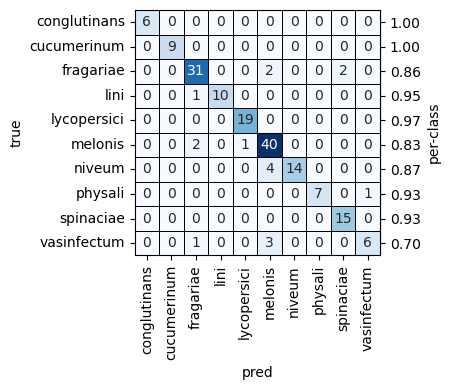

In [18]:
model = BernoulliNB()
# params = {"alpha": np.linspace(0.01, 0.25, 5)}
# result = grid_search(model, params, data, target)
score, pred = evaluate_model(BernoulliNB(alpha=0.07), data, target, verbose=2, n_jobs=4)
print(score)
fig, ax = plot_confusion_matrix(target, pred)

Logistic regression

{'index': 'GCA_016163875.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_001703035.1', 'pred': 'lycopersici', 'true': 'lycopersici'}
{'index': 'GCA_012026625.1', 'pred': 'lini', 'true': 'lini'}
{'index': 'GCA_020975875.1', 'pred': 'melonis', 'true': 'melonis'}
{'index': 'GCA_015227905.1', 'pred': 'spinaciae', 'true': 'spinaciae'}
{'index': 'GCA_016163905.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_001702865.1', 'pred': 'niveum', 'true': 'niveum'}
{'index': 'GCA_000260215.2', 'pred': 'conglutinans', 'true': 'conglutinans'}
{'index': 'GCA_016165865.1', 'pred': 'fragariae', 'true': 'fragariae'}{'index': 'GCA_001703015.1', 'pred': 'lycopersici', 'true': 'lycopersici'}

{'index': 'GCA_016166345.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_014602775.1', 'pred': 'niveum', 'true': 'niveum'}
{'index': 'GCA_001702515.1', 'pred': 'cucumerinum', 'true': 'cucumerinum'}
{'index': 'GCA_014602815.1', 'pred': 'niveum', 'true': 'niveum'}
{'index': 'GCA_01534

0.9665201717132604


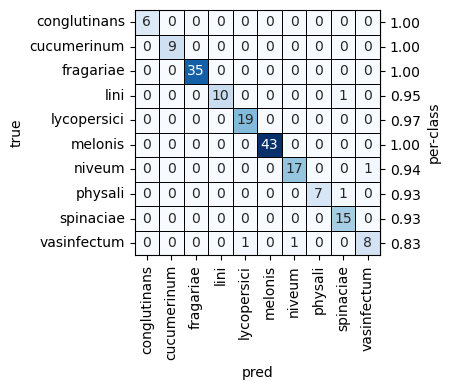

In [ ]:
model = LogisticRegression(
    random_state=0,
    solver="saga",
    max_iter=2000,
    class_weight="balanced",
    tol=1e-3
)
# Elasticnet does not improve; and C > 1 does not improve, but requires more runtime
# params = {"C": [.001, .01, .1, 1., 10.], "l1_ratio": [0., .2, .4, .6, .8, 1.]}
# search = grid_search(model, params, data, target, n_jobs=20, verbose=True)
score, pred = evaluate_model(model, eff, target, n_jobs=12)
print(score)
fig, ax = plot_confusion_matrix(target, pred)

{'index': 'GCA_001702865.1', 'pred': 'niveum', 'true': 'niveum'}
{'index': 'GCA_020975875.1', 'pred': 'melonis', 'true': 'melonis'}
{'index': 'GCA_015227905.1', 'pred': 'spinaciae', 'true': 'spinaciae'}
{'index': 'GCA_001703035.1', 'pred': 'lycopersici', 'true': 'lycopersici'}
{'index': 'GCA_016163905.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_001703015.1', 'pred': 'lycopersici', 'true': 'lycopersici'}
{'index': 'GCA_014602775.1', 'pred': 'niveum', 'true': 'niveum'}
{'index': 'GCA_000260215.2', 'pred': 'conglutinans', 'true': 'conglutinans'}
{'index': 'GCA_016166345.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_016163875.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_012026625.1', 'pred': 'lini', 'true': 'lini'}
{'index': 'GCA_016165865.1', 'pred': 'fragariae', 'true': 'fragariae'}
{'index': 'GCA_001703265.1', 'pred': 'melonis', 'true': 'melonis'}
{'index': 'GCA_020976095.1', 'pred': 'melonis', 'true': 'melonis'}
{'index': 'GCA_001703455.1

0.9064151252537926


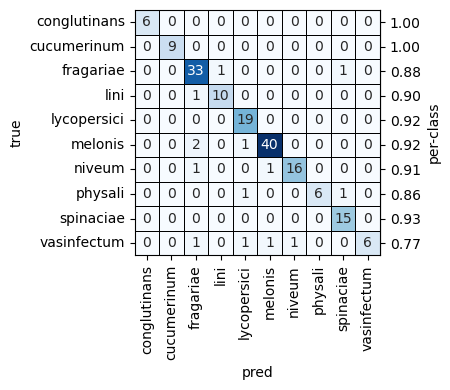

In [32]:
model = LogisticRegression(
    random_state=0,
    solver="saga",
    max_iter=2000,
    class_weight="balanced",
    tol=1e-3
)
# Elasticnet does not improve; and C > 1 does not improve, but requires more runtime
# params = {"C": [.001, .01, .1, 1., 10.], "l1_ratio": [0., .2, .4, .6, .8, 1.]}
# search = grid_search(model, params, data, target, n_jobs=20, verbose=True)
score, pred = evaluate_model(model, pan, target, n_jobs=12, verbose=2)
print(score)
fig, ax = plot_confusion_matrix(target, pred)

LinearSVC

In [ ]:
# pancluster 0.8523
# efectores 0.9665
# pangenoma 0.9203

{'score': 0.9203155655712512}


0.9203155655712512


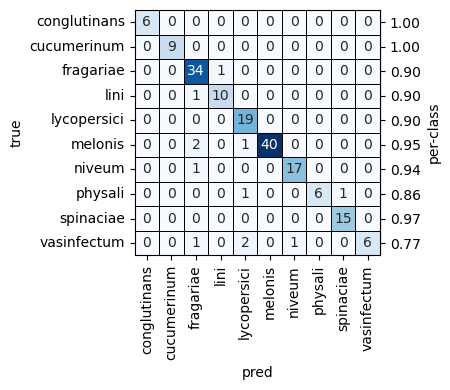

In [37]:
model = LinearSVC(class_weight="balanced", random_state=0, max_iter=5000)
# l1 is worse
# loss, dual, C does not change performance
score, pred = evaluate_model(model, pan, target, n_jobs=12, verbose=True)
print(score)
fig, ax = plot_confusion_matrix(target, pred)
# fig.savefig("heatmap.svg", transparent=True)

In [43]:
sfs: SequentialFeatureSelector = SequentialFeatureSelector(
    LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000),
    k_features=(1, 30),
    verbose=2,
    scoring="matthews_corrcoef",
    cv=3,
    n_jobs=20
).fit(data, target)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 2445 tasks      | elapsed:    1.7s
[Parallel(n_jobs=20)]: Done 2586 out of 2625 | elapsed:    1.8s remaining:    0.0s
[Parallel(n_jobs=20)]: Done 2625 out of 2625 | elapsed:    1.8s finished

[2025-09-02 12:17:54] Features: 1/30 -- score: 0.3229598195486691[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 2490 tasks      | elapsed:    1.7s
[Parallel(n_jobs=20)]: Done 2624 out of 2624 | elapsed:    1.8s finished

[2025-09-02 12:17:56] Features: 2/30 -- score: 0.4703844827192132[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 ta

In [67]:
scores = cross_validate(
    make_pipeline(
        SequentialFeatureSelector(
           LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000),
            k_features=(1, 20),
            scoring="matthews_corrcoef",
            cv=StratifiedKFold(5),
            n_jobs=20,
            verbose=2
        ),
        LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000)
    ),
    data,
    target,
    scoring="matthews_corrcoef",
    cv=StratifiedKFold(6),
    return_estimator=True,
    verbose=10
)

[Parallel(n_jobs=20)]: Done 2445 tasks      | elapsed:    2.7s
[Parallel(n_jobs=20)]: Done 2620 out of 2620 | elapsed:    2.8s finished

[2025-09-02 13:14:11] Features: 6/20 -- score: 0.7314397534422394[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 1920 tasks      | elapsed:    2.2s
[Parallel(n_jobs=20)]: Done 2619 out of 2619 | elapsed:    2.9s finished

[2025-09-02 13:14:14] Features: 7/20 -- score: 0.7631430425701284[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 2475 tasks      | elapsed:    2.8s
[Parallel(n_jobs=20)]: Done 2579 out of 2618 | elapsed:    2.9s remaining:    0.0s
[Parallel(n_jobs=20)]: Done 2618 out of 2618 | e

[CV] END ......................................., score=0.843 total time= 1.0min


[Parallel(n_jobs=20)]: Done 2606 out of 2606 | elapsed:    3.0s finished

[2025-09-02 13:14:55] Features: 20/20 -- score: 0.9611238587312236[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:  6.1min finished


In [16]:
sfs = SequentialFeatureSelector(
    LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000),
    k_features=(1, 30),
    scoring="matthews_corrcoef",
    cv=StratifiedKFold(6),
    n_jobs=20,
    verbose=2
).fit(data, target)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 2460 tasks      | elapsed:    3.0s
[Parallel(n_jobs=20)]: Done 2625 out of 2625 | elapsed:    3.2s finished

[2025-09-02 13:26:03] Features: 1/30 -- score: 0.3254927106413517[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 1920 tasks      | elapsed:    2.5s
[Parallel(n_jobs=20)]: Done 2624 out of 2624 | elapsed:    3.2s finished

[2025-09-02 13:26:07] Features: 2/30 -- score: 0.47276315560876064[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 296 tasks      | elapsed: 

In [37]:
eff, _ = load_dataset("data/tables/effectors.csv", "data/accessions.csv")
eff

,e3,e5,e18,e19,e20,"e51,e168,e179,e200,e223",e69,"e77,e78,e284,e286",e79,e86,...,e1240,e1241,e1242,e1243,e1244,e1245,e1246,e1247,e1248,"e1249,e1250"
accession,,,,,,,,,,,,,,,,,,,,,
GCA_013347365.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_016170085.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
GCA_020975915.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
GCA_001703205.2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
GCA_013347505.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCA_001702745.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_016164135.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_013347535.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [46]:
pan, _ = load_dataset("data/tables/pangenome.csv", "data/accessions.csv")
pan

,g0,g1,g2,g3,g4,g5,g6,g7,g8,g9,...,g72717,g72718,g72719,g72720,g72722,g72723,g72724,g72725,g72727,g72728
accession,,,,,,,,,,,,,,,,,,,,,
GCA_013347365.1,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_016170085.2,1,1,1,1,0,1,1,1,1,1,...,0,0,1,0,1,0,0,0,0,0
GCA_020975915.1,1,1,1,1,1,1,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
GCA_001703205.2,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_013347505.1,1,0,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCA_001702745.1,0,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
GCA_016164135.1,1,0,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_013347535.1,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,1


In [21]:
sfs = SequentialFeatureSelector(
    LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000),
    k_features="best",
    scoring="matthews_corrcoef",
    cv=StratifiedKFold(6),
    n_jobs=20,
    verbose=2
).fit(pan, target)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   4 out of  28 | elapsed:    1.2s remaining:    7.1s
[Parallel(n_jobs=20)]: Done  19 out of  28 | elapsed:    1.5s remaining:    0.7s
[Parallel(n_jobs=20)]: Done  28 out of  28 | elapsed:    1.6s finished

[2025-09-02 23:17:11] Features: 1/28 -- score: 0.364925834207287[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  27 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=20)]: Done  16 out of  27 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  27 out of  27 | elapsed:    0.1s finished

[2025-09-02 23:17:11] Features: 2/28 -- score: 0.4868375433970919[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  15 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  26 out of  26 | elapsed:    0.0s finished

[2025-09-02 23:17:1

score:  0.9598733312794363
n_vars: 21
vars:   ('c10098_g11', 'c10675_g11', 'c11039_g3,c11039_g4', 'c2998_g2,c7614_g3,c7696_g0,c7696_g1,c7696_g2,c7696_g3', 'c3054_g0', 'c3454_g0', 'c3536_g10', 'c3581_g1', 'c4073_g5', 'c4077_g1', 'c4078_g16', 'c4858_g0', 'c5107_g6', 'c6078_g25', 'c6086_g0', 'c6142_g0,c6142_g1,c6142_g13,c6142_g14', 'c6589_g1,c6589_g2,c6589_g3,c6589_g6,c6589_g7', 'c6612_g19,c6612_g20', 'c7067_g16,c7067_g17', 'c9458_g0,c9458_g1,c9458_g2', 'c9591_g0,c9591_g1,c9591_g10,c9591_g2,c9591_g3,c9591_g4,c9591_g6,c9591_g7,c9591_g8,c9591_g9')


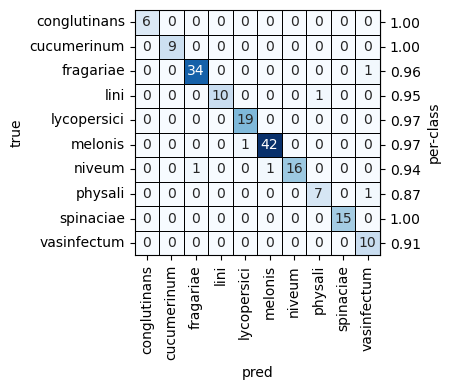

In [58]:
# Pancluster
model = LinearSVC(class_weight="balanced", random_state=0, max_iter=10_000)
seldata = data[list(sfs.k_feature_names_)]
score, pred = evaluate_model(model, seldata, target, n_jobs=20)
print("score: ", score)
print("n_vars:", len(sfs.k_feature_names_))
print("vars:  ", sfs.k_feature_names_)
fig, ax = plot_confusion_matrix(target, pred)
fig.savefig("results/foxy_heatmaps/panclusters_9599_21.pdf", transparent=True)

score:  0.9600987987309012
n_vars: 16
vars:   ('e123', 'e232', 'e257', 'e325', 'e332', 'e353', 'e392,e393,e395,e397', 'e439', 'e455', 'e464', 'e550', 'e710', 'e1165', 'e1197,e1198', 'e1208', 'e1247')


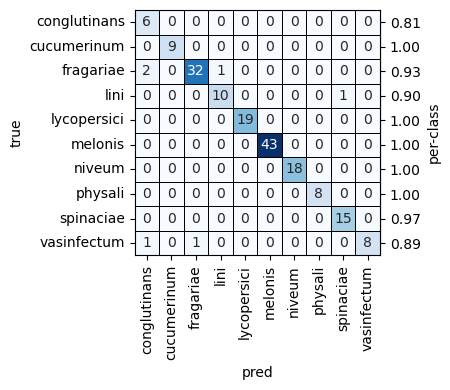

In [61]:
# Effectors
model = LinearSVC(
    C=0.01,
    class_weight="balanced",
    random_state=0,
    max_iter=10_000
)
seldata = eff[list(sfs.k_feature_names_)]
# params = {
#     "C": [0.001, 0.01, 0.1, 1.0, 10.0],
#     "loss": ["squared_hinge", "hinge"],
#     "penalty": ["l2"]
# }
# grid = grid_search(model, params, seldata, target, n_jobs=20)
# max(grid, key=lambda x: x["eval"]["score"])
score, pred = evaluate_model(model, seldata, target, n_jobs=20)
print("score: ", score)
print("n_vars:", len(sfs.k_feature_names_))
print("vars:  ", sfs.k_feature_names_)
fig, ax = plot_confusion_matrix(target, pred)
fig.savefig("results/foxy_heatmaps/effectors_9601_16.pdf", transparent=True)

score:  0.966634899626941
n_vars: 15
vars:   ('g1016', 'g1165', 'g2588', 'g2818,g3149', 'g6850', 'g9839', 'g11518', 'g26710', 'g30427', 'g37155', 'g38070', 'g42457', 'g52192', 'g63190', 'g68260')


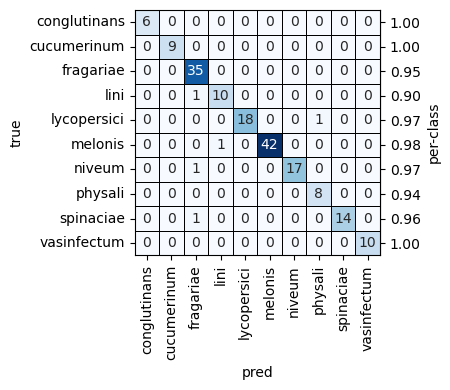

In [23]:
# Pangenome
model = LinearSVC(
    class_weight="balanced",
    random_state=0,
    max_iter=10_000
)
seldata = pan[list(sfs.k_feature_names_)]
# params = {
#     "C": [0.001, 0.01, 0.1, 1.0, 10.0],
#     # "loss": ["squared_hinge", "hinge"],
#     "penalty": ["l1", "l2"]
# }
# grid = grid_search(model, params, seldata, target, n_jobs=20)
# max(grid, key=lambda x: x["eval"]["score"])
score, pred = evaluate_model(model, seldata, target, n_jobs=20)
print("score: ", score)
print("n_vars:", len(sfs.k_feature_names_))
print("vars:  ", sfs.k_feature_names_)
fig, ax = plot_confusion_matrix(target, pred)
fig.savefig("results/foxy_heatmaps/pangenome_9666_15.pdf", transparent=True)

### Selected variables

In [75]:
with open("../temp.txt", "w") as handle:
    print("\n".join(['c10098_g11', 'c10675_g11', 'c11039_g3,c11039_g4', 'c2998_g2,c7614_g3,c7696_g0,c7696_g1,c7696_g2,c7696_g3', 'c3054_g0', 'c3454_g0', 'c3536_g10', 'c3581_g1', 'c4073_g5', 'c4077_g1', 'c4078_g16', 'c4858_g0', 'c5107_g6', 'c6078_g25', 'c6086_g0', 'c6142_g0,c6142_g1,c6142_g13,c6142_g14', 'c6589_g1,c6589_g2,c6589_g3,c6589_g6,c6589_g7', 'c6612_g19,c6612_g20', 'c7067_g16,c7067_g17', 'c9458_g0,c9458_g1,c9458_g2', 'c9591_g0,c9591_g1,c9591_g10,c9591_g2,c9591_g3,c9591_g4,c9591_g6,c9591_g7,c9591_g8,c9591_g9']), file=handle)

In [ ]:
clu = clu[['c10098_g11', 'c10675_g11', 'c11039_g3,c11039_g4', 'c2998_g2,c7614_g3,c7696_g0,c7696_g1,c7696_g2,c7696_g3', 'c3054_g0', 'c3454_g0', 'c3536_g10', 'c3581_g1', 'c4073_g5', 'c4077_g1', 'c4078_g16', 'c4858_g0', 'c5107_g6', 'c6078_g25', 'c6086_g0', 'c6142_g0,c6142_g1,c6142_g13,c6142_g14', 'c6589_g1,c6589_g2,c6589_g3,c6589_g6,c6589_g7', 'c6612_g19,c6612_g20', 'c7067_g16,c7067_g17', 'c9458_g0,c9458_g1,c9458_g2', 'c9591_g0,c9591_g1,c9591_g10,c9591_g2,c9591_g3,c9591_g4,c9591_g6,c9591_g7,c9591_g8,c9591_g9']]

,c10098_g11,c10675_g11,"c11039_g3,c11039_g4","c2998_g2,c7614_g3,c7696_g0,c7696_g1,c7696_g2,c7696_g3",c3054_g0,c3454_g0,c3536_g10,c3581_g1,c4073_g5,c4077_g1,...,c4858_g0,c5107_g6,c6078_g25,c6086_g0,"c6142_g0,c6142_g1,c6142_g13,c6142_g14","c6589_g1,c6589_g2,c6589_g3,c6589_g6,c6589_g7","c6612_g19,c6612_g20","c7067_g16,c7067_g17","c9458_g0,c9458_g1,c9458_g2","c9591_g0,c9591_g1,c9591_g10,c9591_g2,c9591_g3,c9591_g4,c9591_g6,c9591_g7,c9591_g8,c9591_g9"
accession,,,,,,,,,,,,,,,,,,,,,
GCA_016166135.1,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
GCA_001702655.1,0,0,0,0,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
GCA_020976275.1,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
GCA_012610815.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_020976355.1,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCA_000259975.2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
GCA_020976085.1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
GCA_001703135.1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0


{'score': 0.9598733312794363}


0.9598733312794363


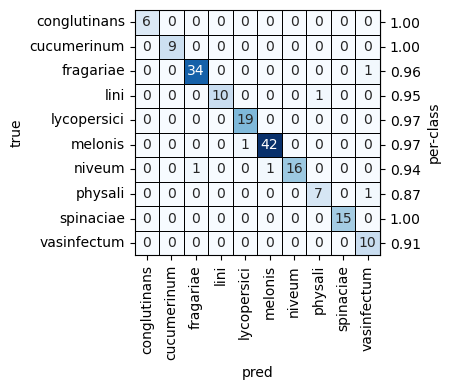

In [20]:
model = LinearSVC(class_weight="balanced", random_state=0, max_iter=5000)
score, pred = evaluate_model(model, clu, target, n_jobs=12, verbose=True)
print(score)
fig, ax = plot_confusion_matrix(target, pred)

In [37]:
clu = clu.rename(columns={
    "c9591_g0,c9591_g1,c9591_g10,c9591_g2,c9591_g3,c9591_g4,c9591_g6,c9591_g7,c9591_g8,c9591_g9": "c9591_g0_g4,g6_g10"
})

In [69]:
clu.columns

Index(['c10098_g11', 'c10675_g11', 'c11039_g3,c11039_g4',
       'c2998_g2,c7614_g3,c7696_g0,c7696_g1,c7696_g2,c7696_g3', 'c3054_g0',
       'c3454_g0', 'c3536_g10', 'c3581_g1', 'c4073_g5', 'c4077_g1',
       'c4078_g16', 'c4858_g0', 'c5107_g6', 'c6078_g25', 'c6086_g0',
       'c6142_g0,c6142_g1,c6142_g13,c6142_g14',
       'c6589_g1,c6589_g2,c6589_g3,c6589_g6,c6589_g7', 'c6612_g19,c6612_g20',
       'c7067_g16,c7067_g17', 'c9458_g0,c9458_g1,c9458_g2',
       'c9591_g0_g4,g6_g10'],
      dtype='object')

1.9369849179434981 -2.479760606720288


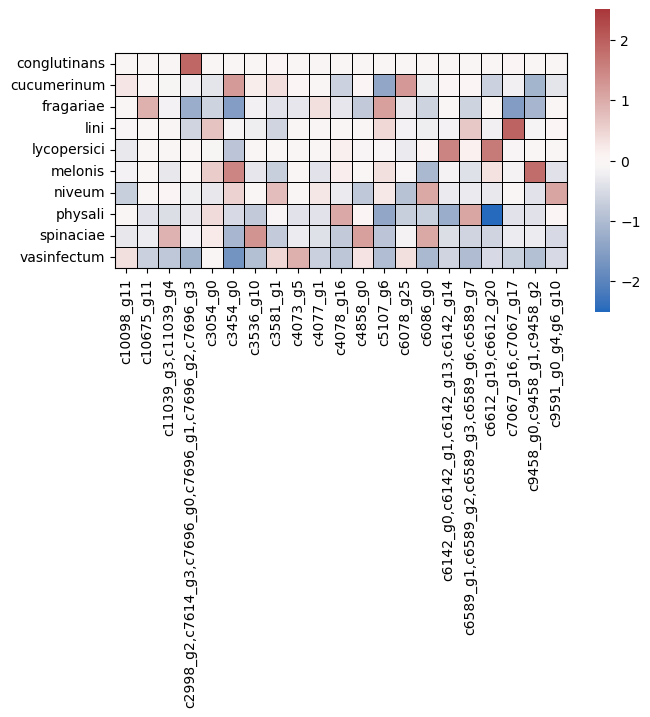

In [63]:
fig, ax = plt.subplots(figsize=(7, 7), layout="tight")
model = model.fit(clu, target)
df = pd.DataFrame(
    model.fit(clu, target).coef_,
    index=model.classes_,
    columns=clu.columns
)
print(np.max(df.values), np.min(df.values))
sns.heatmap(
    df,
    square=True,
    cmap="vlag",
    linecolor="black",
    linewidths=0.6,
    ax=ax,
    vmin=-2.5,
    vmax=2.5
)
for spine in ax.spines.values():
    spine.set_visible(True)
fig.savefig("results/pancluster_coef.pdf", transparent=True)

### Archived

MCA + GaussianNB

In [10]:
model = make_pipeline(
    VarianceThreshold(),
    FunctionTransformer(to_pandas),
    prince.MCA(n_components=100, check_input=False, random_state=0, one_hot=False, n_iter=50),
    StandardScaler(),
    GaussianNB()
)
evaluate_model(model, data, target, verbose=1)

{'score': 0.7449816719943597}


(0.7449816719943597,
 [np.str_('melonis'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('niveum'),
  np.str_('niveum'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('melonis'),
  np.str_('niveum'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('lycopersici'),
  np.str_('fragariae'),
  np.str_('niveum'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('melonis'),
  np.str_('melonis'),
  np.str_('conglutinans'),
  np.str_('fragariae'),
  np.str_('lycopersici'),
  np.str_('physali'),
  np.str_('melonis'),
  np.str_('lycopersici'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('lycopersici'),
  np.str_('fragariae'),
  np.str_('cucumerinum'),
  np.str_('lycopersici'),
  np.str_('fragariae'),
  np.str_('fragariae'),
  np.str_('melonis'),
  np.str_('fragariae'),
  np.str_('melonis'),
  np.str_('melonis'),
  np.str_('melonis'),
  np.str_('fragariae'),
  np.str_('lini'),
  np.str_('fragariae'),
  np.str_('lycope

OVO + BernoulliNB

In [12]:
model = make_pipeline(
    OneVsOneClassifier(BernoulliNB(alpha=0.07))
)
evaluate_model(model, data, target)

(0.7721215872276468,
 ['melonis',
  'fragariae',
  'fragariae',
  'niveum',
  'niveum',
  'fragariae',
  'niveum',
  'niveum',
  'niveum',
  'fragariae',
  'spinaciae',
  'lycopersici',
  'spinaciae',
  'cucumerinum',
  'fragariae',
  'fragariae',
  'niveum',
  'melonis',
  'conglutinans',
  'vasinfectum',
  'lycopersici',
  'physali',
  'melonis',
  'lycopersici',
  'vasinfectum',
  'fragariae',
  'fragariae',
  'physali',
  'fragariae',
  'cucumerinum',
  'lycopersici',
  'fragariae',
  'fragariae',
  'lycopersici',
  'fragariae',
  'melonis',
  'melonis',
  'melonis',
  'spinaciae',
  'lini',
  'fragariae',
  'physali',
  'cucumerinum',
  'lycopersici',
  'melonis',
  'fragariae',
  'melonis',
  'vasinfectum',
  'niveum',
  'lycopersici',
  'fragariae',
  'fragariae',
  'lycopersici',
  'lycopersici',
  'spinaciae',
  'fragariae',
  'melonis',
  'cucumerinum',
  'vasinfectum',
  'lini',
  'melonis',
  'lycopersici',
  'vasinfectum',
  'fragariae',
  'lycopersici',
  'spinaciae',
  '

SFS + BernoulliNB

In [ ]:
model = make_pipeline(
    SequentialFeatureSelector(
        BernoulliNB(alpha=0.07),
        n_features_to_select="auto",
        tol=0.01,
        scoring="matthews_corrcoef",
        cv=3
    ),
    BernoulliNB(alpha=0.07)
)
score, pred = evaluate_model(model, data, target, n_jobs=20, verbose=2)

(<Figure size 400x400 with 1 Axes>, <Axes: xlabel='pred', ylabel='true'>)

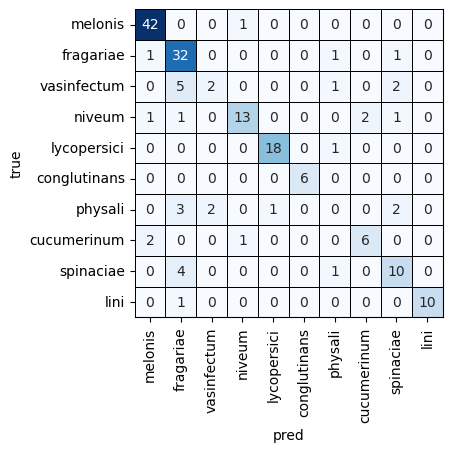

In [62]:
plot_confusion_matrix(target, pred)

In [77]:
df = pd.read_csv("out.csv", header=None)
df

,0,1
0,c10098_g11,AGND01000289.1.region001_ORF5:gid::pid:ncbi_FU...
1,c10675_g11,WIMK01000119.1.region001_ORF11:gid::pid:ncbi_F...
2,c11039_g3,JAALGI010000110.1.region001_ORF2:gid::pid:ncbi...
3,c11039_g4,JAALGI010000110.1.region001_ORF1:gid::pid:ncbi...
4,c2998_g2,AFQF01004229.1.region001_ORF1:gid::pid:ncbi_FU...
5,c7614_g3,AFQF01000390.1.region001_ORF5:gid::pid:ncbi_FU...
6,c7696_g0,AFQF01005327.1.region001_ORF4:gid::pid:ncbi_FU...
7,c7696_g1,AFQF01005327.1.region001_ORF3:gid::pid:ncbi_FU...
8,c7696_g2,AFQF01005327.1.region001_ORF2:gid::pid:ncbi_FU...
9,c7696_g3,AFQF01005327.1.region001_ORF1:gid::pid:ncbi_FU...


In [11]:
data, target = load_dataset("data/tables/panclusters.csv", "data/accessions.csv")
data

FileNotFoundError: [Errno 2] No such file or directory: 'data/tables/panclusters.csv'

In [12]:
target.value_counts()

NameError: name 'target' is not defined

In [140]:
data.loc[target[target != "physali"].index, data.columns[data.columns.str.contains("c6612")]].sum().to_frame()

,0
"c10728_g52,c10738_g28,c4079_g10,c4079_g17,c6612_g29",0
"c10738_g21,c11211_g10,c11211_g2,c11211_g8,c11211_g9,c11261_g26,c11768_g4,c11768_g5,c11768_g6,c4431_g18,c4435_g0,c4435_g1,c4435_g10,c4435_g11,c4435_g12,c4435_g13,c4435_g2,c4435_g3,c4435_g4,c4435_g5,c4435_g6,c4435_g7,c4435_g8,c4435_g9,c4456_g0,c4456_g1,c4456_g2,c4456_g3,c4456_g4,c4456_g5,c4458_g7,c4472_g0,c4472_g1,c4496_g11,c5005_g4,c5005_g5,c6060_g24,c6612_g28,c8191_g4,c8191_g5,c8191_g6,c8191_g7,c8823_g4,c8823_g5",1
"c11260_g15,c11260_g16,c3199_g13,c3199_g14,c3199_g15,c3549_g16,c6612_g27,c7963_g44,c7963_g45,c8191_g10,c8191_g11,c8191_g8,c8191_g9",1
c6612_g0,31
c6612_g1,41
"c6612_g10,c6612_g9,c7067_g1",2
c6612_g11,3
"c6612_g12,c6612_g13",43
"c6612_g14,c6612_g15,c6612_g16,c6612_g18,c6612_g7",46
"c6612_g17,c6612_g8",41


In [86]:
result: Dict[str, str] = {}

for _, (fam, gene) in df.iterrows():
    fam: str
    gene: str
    bgc = gene.split("_", maxsplit=1)[0]
    found = False
    with open(f"data/gcfs/cache/fasta/{bgc}.fasta") as handle:
        for line in handle:
            line = line.strip()
            if found:
                result[f"{gene}_{fam}"] = line
            if line[1:] == gene:
                found = True
with open("selected.fasta", "w", encoding="utf8") as handle:
    for label, seq in result.items():
        print(f">{label}", file=handle)
        print(seq, file=handle)